# Convolutional Neural Network

In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import os
import random
import shutil
from PIL import Image

In [2]:

def split_dataset(source_dir, output_dir, train_percentage=80):
    classes = ["Cat", "Dog"]

    for class_name in classes:
        source_class = os.path.join(source_dir, class_name)

        images = [
            file for file in os.listdir(source_class)
            if file.lower().endswith((".jpg", ".jpeg", ".png", ".bmp", ".webp"))
        ]

        random.shuffle(images)

        split_index = int(len(images) * train_percentage / 100)

        train_images = images[:split_index]
        test_images = images[split_index:]

        train_folder = os.path.join(output_dir, "train", class_name)
        test_folder = os.path.join(output_dir, "test", class_name)

        os.makedirs(train_folder, exist_ok=True)
        os.makedirs(test_folder, exist_ok=True)

        for image in train_images:
            shutil.copy2(
                os.path.join(source_class, image),
                os.path.join(train_folder, image)
            )

        for image in test_images:
            shutil.copy2(
                os.path.join(source_class, image),
                os.path.join(test_folder, image)
            )

    print("Dataset split successfully")

In [3]:
split_dataset(
    source_dir="PetImages",
    output_dir="cat_dog_split",
    train_percentage=80
)

Dataset split successfully


In [4]:
for root, dirs, files in os.walk("cat_dog_split"):
    for file in files:
        path = os.path.join(root, file)

        try:
            img = Image.open(path)
            img = img.convert("RGB")
            img = img.resize((128, 128))
            img.save(path)

        except:
            os.remove(path)
            print("Deleted:", path)

print("Cleaning Done")

C:\Users\agraw\Downloads\anaconda3\Lib\site-packages\PIL\TiffImagePlugin.py:949: UserWarning: Truncated File Read
  warnings.warn(str(msg))


Cleaning Done


In [5]:

train_dataset = tf.keras.utils.image_dataset_from_directory(
    "cat_dog_split/train",
    image_size=(128, 128),
    batch_size=32
)

test_dataset = tf.keras.utils.image_dataset_from_directory(
    "cat_dog_split/test",
    image_size=(128, 128),
    batch_size=32
)


Found 24664 files belonging to 2 classes.
Found 10429 files belonging to 2 classes.


In [6]:

print("Classes:", train_dataset.class_names)


Classes: ['Cat', 'Dog']


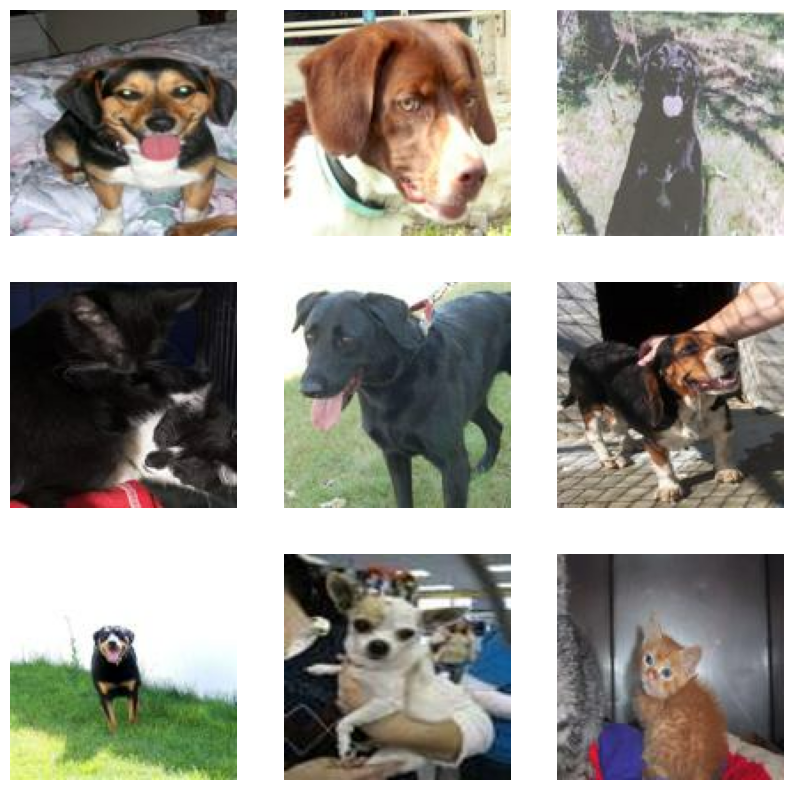

In [7]:
plt.figure(figsize=(10, 10))

for images, labels in train_dataset.take(1):
    for i in range(9):
        plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.axis("off")

plt.show()


In [8]:
model = tf.keras.Sequential([

    tf.keras.layers.Rescaling(1./255, input_shape=(128, 128, 3)),

    tf.keras.layers.Conv2D(32, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(128, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Dense(1, activation='sigmoid')
])

C:\Users\agraw\Downloads\anaconda3\Lib\site-packages\keras\src\layers\preprocessing\data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [9]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)                │ (None, 128, 128, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d (Conv2D)                      │ (None, 126, 126, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 63, 63, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 61, 61, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 30, 30, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 28, 28, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 14, 14, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 25088)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │       3,211,392 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,304,769 (12.61 MB)

 Trainable params: 3,304,769 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [10]:

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [11]:

history = model.fit(
    train_dataset,
    validation_data=test_dataset,
    epochs=10
)

Epoch 1/10
771/771 ━━━━━━━━━━━━━━━━━━━━ 157s 201ms/step - accuracy: 0.6536 - loss: 0.6134 - val_accuracy: 0.7309 - val_loss: 0.5516
Epoch 2/10
771/771 ━━━━━━━━━━━━━━━━━━━━ 164s 213ms/step - accuracy: 0.7646 - loss: 0.4875 - val_accuracy: 0.8248 - val_loss: 0.3918
Epoch 3/10
771/771 ━━━━━━━━━━━━━━━━━━━━ 165s 214ms/step - accuracy: 0.8178 - loss: 0.4051 - val_accuracy: 0.8508 - val_loss: 0.3415
Epoch 4/10
771/771 ━━━━━━━━━━━━━━━━━━━━ 150s 194ms/step - accuracy: 0.8530 - loss: 0.3376 - val_accuracy: 0.8890 - val_loss: 0.2686
Epoch 5/10
771/771 ━━━━━━━━━━━━━━━━━━━━ 157s 203ms/step - accuracy: 0.8855 - loss: 0.2710 - val_accuracy: 0.9151 - val_loss: 0.2086
Epoch 6/10
771/771 ━━━━━━━━━━━━━━━━━━━━ 177s 229ms/step - accuracy: 0.9111 - loss: 0.2134 - val_accuracy: 0.9278 - val_loss: 0.1748
Epoch 7/10
771/771 ━━━━━━━━━━━━━━━━━━━━ 185s 240ms/step - accuracy: 0.9347 - loss: 0.1644 - val_accuracy: 0.9495 - val_loss: 0.1322
Epoch 8/10
771/771 ━━━━━━━━━━━━━━━━━━━━ 184s 238ms/step - accuracy: 0.9466 -

In [12]:

loss, accuracy = model.evaluate(test_dataset)

print("\nAccuracy:", accuracy)
print("Loss:", loss)

326/326 ━━━━━━━━━━━━━━━━━━━━ 18s 55ms/step - accuracy: 0.9742 - loss: 0.0775

Accuracy: 0.9742065668106079
Loss: 0.07745224982500076


In [13]:
img = tf.keras.preprocessing.image.load_img(
    "2355.jpg",
    target_size=(128, 128)
)

img_array = tf.keras.preprocessing.image.img_to_array(img)

img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array)

print("Prediction Score:", prediction[0][0])

if prediction[0][0] > 0.5:
    print("Dog")
else:
    print("Cat")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step
Prediction Score: 1.0
Dog
